# SCADA Power Output Decomposition

This notebook performs MSTL decomposition on wind turbine power output data.

**Configuration:**
Edit variables in Step 3 to customize:
- `turbine_id`: Single turbine (e.g., '1') or 'all' for averaged analysis
  - Single turbine: Decomposes data from one specific turbine
  - 'all': Averages power across all 6 turbines at each timestamp, then decomposes the averaged series
- `patterns`: Seasonality patterns to extract ('daily', 'weekly', 'monthly', 'yearly')
- `cap_outliers`: Enable extreme outlier capping
- `outlier_threshold`: Number of std deviations for outlier detection
- `interpolation_limit`: Maximum gap size to interpolate (in minutes)
- `use_robust`: Use robust MSTL mode

**Note:** For yearly patterns, at least 2 years of data are required.

**Steps:**
1. Imports
2. Load raw data
3. Configuration
4. Select turbine(s) and aggregate if needed
5. Preprocess data
6. Analyze gaps
7. Resample to 10-minute intervals
8. Interpolate missing values
9. Cap extreme outliers
10. Apply MSTL decomposition
11. Visualize and save results

## Step 1: Imports

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import json
from pathlib import Path

SDK_PATH = Path().resolve().parents[2] / "src" / "sdk" / "python"
sys.path.insert(0, str(SDK_PATH))

from rtdip_sdk.pipelines.decomposition.pandas import MSTLDecomposition
from rtdip_sdk.pipelines.visualization.matplotlib.decomposition import MSTLDecompositionPlot

# Create output directory for images
OUTPUT_DIR = Path("output_images")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Imports complete")
print(f"Output directory: {OUTPUT_DIR.absolute()}")

Imports complete
Output directory: c:\Users\Agando\Documents\Projects\amos2025ws03-rtdip-timeseries-forecasting\amos_team_resources\scada\decomposition\output_images


## Step 2: Load Data

Two options:
- **Option A**: Load preprocessed parquet (faster)
- **Option B**: Load raw CSV files (slower, more control)

Set `use_preprocessed = True` to use Option A.

In [40]:
use_preprocessed = True

if use_preprocessed:
    print("Loading preprocessed data...")
    preprocessed_file = Path().resolve().parent / "preprocessing" / "scada_prepro.parquet"
    
    if not preprocessed_file.exists():
        raise FileNotFoundError(
            f"Preprocessed file not found: {preprocessed_file}\n"
            "Run the preprocessing notebook first or set use_preprocessed=False"
        )
    
    df = pd.read_parquet(preprocessed_file, columns=['item_id', 'timestamp', 'target'])
    
    print(f"Loaded {len(df):,} rows")
    print(f"Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
    print(f"Turbines: {sorted(df['item_id'].unique())}")
    
else:
    print("Loading raw CSV files...")
    data_dir = Path().resolve().parent / "data" / "raw" / "scada_2020"
    
    print(f"Loading from: {data_dir}")
    print(f"Directory exists: {data_dir.exists()}")
    print()
    
    csv_files = sorted(data_dir.glob("Turbine_Data_Kelmarsh_*.csv"))
    print(f"Found {len(csv_files)} turbine data files")
    
    dfs = []
    for i, file in enumerate(csv_files, 1):
        print(f"Reading: {file.name}")
        df_temp = pd.read_csv(
            file,
            skiprows=9,
            header=0,
            low_memory=False,
            on_bad_lines='skip'
        )
        df_temp.columns = [c.lstrip('# ').strip() for c in df_temp.columns]
        df_temp = df_temp.rename(columns={'Date and time': 'timestamp', 'Power (kW)': 'target'})
        df_temp = df_temp[['timestamp', 'target']]
        df_temp['item_id'] = f'{i}_Kelmarsh'
        dfs.append(df_temp)
    
    df = pd.concat(dfs, ignore_index=True)
    del dfs
    
    print(f"\nLoaded {len(df):,} rows")
    print(f"Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
    print(f"Turbines: {sorted(df['item_id'].unique())}")

df.head()

Loading preprocessed data...
Loaded 313,440 rows
Memory: 24.8 MB
Turbines: ['1_Kelmarsh', '2_Kelmarsh', '3_Kelmarsh', '4_Kelmarsh', '5_Kelmarsh', '6_Kelmarsh']


,item_id,timestamp,target
0,1_Kelmarsh,2020-01-01 00:00:00,150.984141
1,1_Kelmarsh,2020-01-01 00:10:00,130.414782
2,1_Kelmarsh,2020-01-01 00:20:00,146.401656
3,1_Kelmarsh,2020-01-01 00:30:00,84.296224
4,1_Kelmarsh,2020-01-01 00:40:00,94.994105


## Step 3: Configuration

In [41]:
# Turbine selection: '1', '2', ..., '6', or 'all'
turbine_id = 'all'

# Seasonality patterns to extract
# Options: ['daily'], ['weekly'], ['monthly'], ['yearly'], or combinations
# Note: yearly requires at least 2 years of data
patterns = ['daily', 'weekly', 'monthly']

# Outlier handling
cap_outliers = True
outlier_threshold = 20.0

# Interpolation
# Maximum gap size to interpolate in minutes (None = interpolate all gaps)
interpolation_limit = None

# MSTL robust mode
use_robust = False

print("Configuration:")
print(f"  Turbine: {turbine_id}")
print(f"  Patterns: {patterns}")
print(f"  Cap outliers: {cap_outliers}")
if cap_outliers:
    print(f"    Threshold: {outlier_threshold} std")
print(f"  Interpolation limit: {interpolation_limit if interpolation_limit else 'none (all gaps)'}")
print(f"  Robust mode: {use_robust}")

Configuration:
  Turbine: all
  Patterns: ['daily', 'weekly', 'monthly']
  Cap outliers: True
    Threshold: 20.0 std
  Interpolation limit: none (all gaps)
  Robust mode: False


## Step 4: Select Turbine(s) and Aggregate if Needed

In [42]:
if turbine_id.lower() == 'all':
    print("Averaging all turbines")
    # Group by timestamp and average power across all turbines
    df_selected = df.groupby('timestamp', as_index=False)['target'].mean()
    print(f"Averaged data: {len(df_selected):,} timestamps from {df['item_id'].nunique()} turbines")
else:
    print(f"Filtering to turbine: {turbine_id}")
    # Convert turbine_id to match item_id format in preprocessed data
    item_id_to_select = f"{turbine_id}_Kelmarsh"
    df_selected = df[df['item_id'] == item_id_to_select].copy()
    # Keep only timestamp and target columns
    df_selected = df_selected[['timestamp', 'target']]
    print(f"Selected turbine has {len(df_selected):,} rows")

del df
df_selected.head()

Averaging all turbines
Averaged data: 52,287 timestamps from 6 turbines


,timestamp,target
0,2020-01-01 00:00:00,288.482490
1,2020-01-01 00:10:00,210.875674
2,2020-01-01 00:20:00,191.306310
3,2020-01-01 00:30:00,105.439707
4,2020-01-01 00:40:00,113.077937


## Step 5: Preprocess Data

In [43]:
print("Preprocessing...")
print()

df_selected['timestamp'] = pd.to_datetime(df_selected['timestamp'], errors='coerce')
invalid_times = df_selected['timestamp'].isna().sum()
if invalid_times > 0:
    df_selected = df_selected.dropna(subset=['timestamp'])
    print(f"Dropped {invalid_times:,} invalid timestamps")
else:
    print("All timestamps valid")

df_selected['target'] = pd.to_numeric(df_selected['target'], errors='coerce')

before_len = len(df_selected)
df_selected = df_selected[df_selected['target'].notna()].copy()
removed = before_len - len(df_selected)
print(f"Removed {removed:,} null target values ({removed/before_len*100:.2f}%)")
print(f"Remaining: {len(df_selected):,} rows")
print()

df_selected = df_selected.sort_values('timestamp').reset_index(drop=True)
print("Sorted by time")
print()

print(f"Time range: {df_selected['timestamp'].min()} to {df_selected['timestamp'].max()}")
duration = df_selected['timestamp'].max() - df_selected['timestamp'].min()
print(f"Duration: {duration.days} days ({duration.days/365.25:.2f} years)")
print()
print("Power statistics:")
print(df_selected['target'].describe())

Preprocessing...

All timestamps valid
Removed 0 null target values (0.00%)
Remaining: 52,287 rows

Sorted by time

Time range: 2020-01-01 00:00:00 to 2020-12-31 23:50:00
Duration: 365 days (1.00 years)

Power statistics:
count    52287.000000
mean       695.732796
std        646.264120
min        -10.807044
25%        153.680263
50%        474.538449
75%       1139.089101
max       2059.511581
Name: target, dtype: float64


## Step 6: Analyze Sampling Pattern

In [44]:
print("Analyzing sampling intervals...")
print("="*80)

time_diffs = df_selected['timestamp'].diff().dropna()

print("\nSampling statistics:")
print(f"  Median:  {time_diffs.median()}")
print(f"  Mean:    {time_diffs.mean()}")
print(f"  Min:     {time_diffs.min()}")
print(f"  Max:     {time_diffs.max()}")
print()
print("Percentiles:")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  {p:2d}th: {time_diffs.quantile(p/100)}")

median_interval = time_diffs.median()
gap_threshold = median_interval * 2
gaps = time_diffs[time_diffs > gap_threshold]

print(f"\nGaps larger than {gap_threshold}: {len(gaps)}")
if len(gaps) > 0:
    print("\nLargest 5 gaps:")
    for i, (idx, gap_size) in enumerate(gaps.nlargest(5).items(), 1):
        gap_start = df_selected.loc[idx-1, 'timestamp']
        gap_end = df_selected.loc[idx, 'timestamp']
        print(f"  {i}. {gap_size} from {gap_start} to {gap_end}")

Analyzing sampling intervals...

Sampling statistics:
  Median:  0 days 00:10:00
  Mean:    0 days 00:10:04.785219
  Min:     0 days 00:10:00
  Max:     0 days 21:50:00

Percentiles:
  25th: 0 days 00:10:00
  50th: 0 days 00:10:00
  75th: 0 days 00:10:00
  90th: 0 days 00:10:00
  95th: 0 days 00:10:00
  99th: 0 days 00:10:00

Gaps larger than 0 days 00:20:00: 18

Largest 5 gaps:
  1. 0 days 21:50:00 from 2020-06-08 18:20:00 to 2020-06-09 16:10:00
  2. 0 days 06:50:00 from 2020-08-25 07:50:00 to 2020-08-25 14:40:00
  3. 0 days 05:40:00 from 2020-09-21 08:40:00 to 2020-09-21 14:20:00
  4. 0 days 05:40:00 from 2020-09-22 08:30:00 to 2020-09-22 14:10:00
  5. 0 days 05:00:00 from 2020-05-05 02:50:00 to 2020-05-05 07:50:00


## Step 7: Resample to 10-Minute Intervals

In [45]:
print("Resampling to 10-minute intervals...")
print("="*80)

resample_freq = '10min'
print(f"Resampling frequency: {resample_freq}")
print(f"Aggregation: mean")
print()

df_resampled = df_selected.set_index('timestamp').resample(resample_freq)['target'].mean().reset_index()

print(f"Original points: {len(df_selected):,}")
print(f"Resampled to: {len(df_resampled):,} intervals")
print()

missing_count = df_resampled['target'].isna().sum()
print(f"Missing values after resampling: {missing_count:,} ({missing_count/len(df_resampled)*100:.2f}%)")

if missing_count > 0:
    is_nan = df_resampled['target'].isna()
    nan_groups = (is_nan != is_nan.shift()).cumsum()
    nan_sequences = df_resampled[is_nan].groupby(nan_groups).size()
    
    print(f"\nGap analysis:")
    print(f"  Number of gaps: {len(nan_sequences)}")
    print(f"  Smallest gap: {nan_sequences.min()} intervals ({nan_sequences.min()*10} min)")
    print(f"  Largest gap: {nan_sequences.max()} intervals ({nan_sequences.max()*10/60:.1f} hours)")
    print(f"  Mean gap: {nan_sequences.mean():.1f} intervals")
    print(f"  Median gap: {nan_sequences.median():.0f} intervals")

df_resampled.head(10)

Resampling to 10-minute intervals...
Resampling frequency: 10min
Aggregation: mean

Original points: 52,287
Resampled to: 52,704 intervals

Missing values after resampling: 417 (0.79%)

Gap analysis:
  Number of gaps: 26
  Smallest gap: 1 intervals (10 min)
  Largest gap: 130 intervals (21.7 hours)
  Mean gap: 16.0 intervals
  Median gap: 7 intervals


,timestamp,target
0,2020-01-01 00:00:00,288.482490
1,2020-01-01 00:10:00,210.875674
2,2020-01-01 00:20:00,191.306310
3,2020-01-01 00:30:00,105.439707
4,2020-01-01 00:40:00,113.077937
5,2020-01-01 00:50:00,269.972712
6,2020-01-01 01:00:00,415.248833
7,2020-01-01 01:10:00,348.772672
8,2020-01-01 01:20:00,319.828144
9,2020-01-01 01:30:00,296.222398


## Step 8: Interpolate Missing Values

In [46]:
print("Interpolating missing values...")
print("="*80)

missing_before = df_resampled['target'].isna().sum()
print(f"Missing values before interpolation: {missing_before:,}")
print(f"Interpolation method: time-based")
if interpolation_limit:
    print(f"Limit: {interpolation_limit} minutes ({interpolation_limit/10:.0f} intervals)")
    limit_intervals = int(interpolation_limit / 10)
else:
    print(f"Limit: None (all gaps)")
    limit_intervals = None
print()

df_interpolated = df_resampled.set_index('timestamp')
df_interpolated['target'] = df_interpolated['target'].interpolate(
    method='time',
    limit=limit_intervals,
    limit_direction='both'
)
df_interpolated = df_interpolated.reset_index()

missing_after = df_interpolated['target'].isna().sum()
interpolated_count = missing_before - missing_after

print(f"Interpolated: {interpolated_count:,} values ({interpolated_count/len(df_interpolated)*100:.2f}%)")
print(f"Remaining NaN: {missing_after:,}")

if missing_after > 0:
    print(f"\nRemoving remaining NaN values...")
    df_interpolated = df_interpolated.dropna(subset=['target']).reset_index(drop=True)
    print(f"Final dataset: {len(df_interpolated):,} rows")

print(f"\nComplete dataset: {df_interpolated['target'].notna().all()}")

Interpolating missing values...
Missing values before interpolation: 417
Interpolation method: time-based
Limit: None (all gaps)

Interpolated: 417 values (0.79%)
Remaining NaN: 0

Complete dataset: True


## Step 9: Cap Extreme Outliers

In [47]:
if cap_outliers:
    print("Checking for extreme outliers...")
    print("="*80)
    
    mean = df_interpolated['target'].mean()
    std = df_interpolated['target'].std()
    
    lower_extreme = mean - outlier_threshold * std
    upper_extreme = mean + outlier_threshold * std
    
    extreme_mask = (df_interpolated['target'] < lower_extreme) | (df_interpolated['target'] > upper_extreme)
    extreme_count = extreme_mask.sum()
    
    print(f"Data statistics:")
    print(f"  Mean: {mean:.4f}")
    print(f"  Std: {std:.4f}")
    print(f"Extreme outlier threshold ({outlier_threshold} std):")
    print(f"  Lower: {lower_extreme:.4f}")
    print(f"  Upper: {upper_extreme:.4f}")
    print(f"Found {extreme_count} extreme outliers ({extreme_count/len(df_interpolated)*100:.3f}%)")
    print()
    
    if extreme_count > 0:
        q99_9 = df_interpolated['target'].quantile(0.999)
        q00_1 = df_interpolated['target'].quantile(0.001)
        
        cap_lower = (df_interpolated['target'] < lower_extreme) & (df_interpolated['target'] < q00_1)
        cap_upper = (df_interpolated['target'] > upper_extreme) & (df_interpolated['target'] > q99_9)
        outliers_total = cap_lower.sum() + cap_upper.sum()
        
        print(f"Capping thresholds:")
        print(f"  Lower (0.1st percentile): {q00_1:.4f}")
        print(f"  Upper (99.9th percentile): {q99_9:.4f}")
        print(f"Values to cap: {outliers_total}")
        print()
        
        if outliers_total > 0:
            extreme_values = df_interpolated[extreme_mask].copy()
            extreme_high = extreme_values.nlargest(min(5, len(extreme_values)), 'target')
            extreme_low = extreme_values.nsmallest(min(5, len(extreme_values)), 'target')
            
            if len(extreme_high) > 0:
                print("Most extreme high values:")
                for idx, row in extreme_high.iterrows():
                    print(f"  {row['timestamp']}: {row['target']:.4f}")
            
            if len(extreme_low) > 0 and extreme_low['target'].min() < lower_extreme:
                print("Most extreme low values:")
                for idx, row in extreme_low.iterrows():
                    if row['target'] < lower_extreme:
                        print(f"  {row['timestamp']}: {row['target']:.4f}")
            print()
            
            df_interpolated['target'] = df_interpolated['target'].clip(lower=q00_1, upper=q99_9)
            
            print(f"After capping:")
            print(f"  Min: {df_interpolated['target'].min():.4f}")
            print(f"  Max: {df_interpolated['target'].max():.4f}")
            
            outlier_metadata = {
                'method': 'std_deviation + percentile',
                'std_threshold': outlier_threshold,
                'lower_percentile': 0.001,
                'upper_percentile': 0.999,
                'outliers_capped': int(outliers_total)
            }
        else:
            print("No values need capping")
            outlier_metadata = {
                'method': 'std_deviation + percentile',
                'std_threshold': outlier_threshold,
                'outliers_capped': 0
            }
    else:
        print("No extreme outliers to cap")
        outlier_metadata = {
            'method': 'std_deviation + percentile',
            'std_threshold': outlier_threshold,
            'outliers_capped': 0
        }
else:
    print("Skipping outlier capping")
    outlier_metadata = {
        'method': 'none',
        'outliers_capped': 0
    }

Checking for extreme outliers...
Data statistics:
  Mean: 692.4696
  Std: 646.0346
Extreme outlier threshold (20.0 std):
  Lower: -12228.2231
  Upper: 13613.1624
Found 0 extreme outliers (0.000%)

No extreme outliers to cap


## Step 10: Visualize Data Before Decomposition

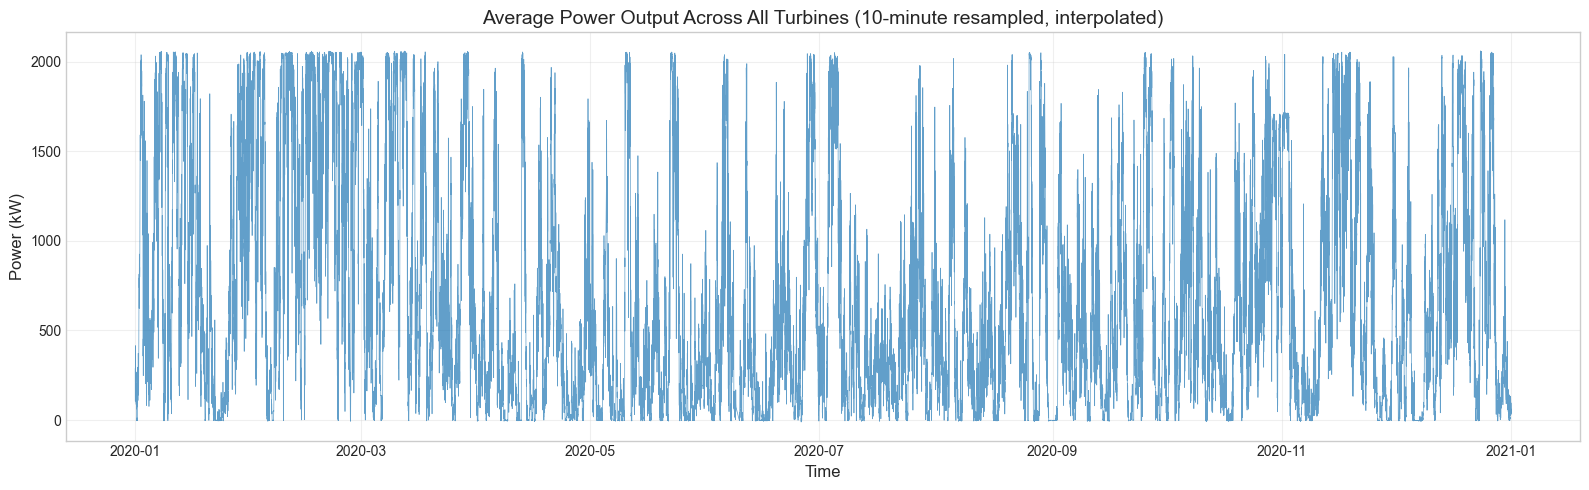

Saved: output_images\data_before_decomposition.png

Data characteristics:
  Mean: 692.47 kW
  Std: 646.03 kW
  Min: -10.81 kW
  Max: 2059.51 kW


In [48]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_interpolated['timestamp'], df_interpolated['target'], linewidth=0.5, alpha=0.7)
if turbine_id.lower() == 'all':
    title = "Average Power Output Across All Turbines"
else:
    title = f"Turbine {turbine_id} - Power Output"
ax.set_title(f"{title} (10-minute resampled, interpolated)")
ax.set_xlabel('Time')
ax.set_ylabel('Power (kW)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
output_file = OUTPUT_DIR / 'data_before_decomposition.png'
plt.savefig(output_file, dpi=150)
plt.show()

print(f"Saved: {output_file}")
print(f"\nData characteristics:")
print(f"  Mean: {df_interpolated['target'].mean():.2f} kW")
print(f"  Std: {df_interpolated['target'].std():.2f} kW")
print(f"  Min: {df_interpolated['target'].min():.2f} kW")
print(f"  Max: {df_interpolated['target'].max():.2f} kW")

## Step 11: Apply MSTL Decomposition

In [49]:
print("Applying MSTL Decomposition...")
print("="*80)

# Calculate periods (10-minute intervals)
daily_period = 6 * 24  # 144 intervals per day
weekly_period = 6 * 24 * 7  # 1008 intervals per week
monthly_period = 6 * 24 * 30  # ~4320 intervals per month (approximate)
yearly_period = 6 * 24 * 365  # ~52560 intervals per year (approximate)

pattern_map = {
    'daily': daily_period,
    'weekly': weekly_period,
    'monthly': monthly_period,
    'yearly': yearly_period
}

periods = []
for pattern in patterns:
    if pattern not in pattern_map:
        raise ValueError(f"Unknown pattern '{pattern}'. Valid: {list(pattern_map.keys())}")
    
    period = pattern_map[pattern]
    min_required = period * 2
    
    if pattern == 'yearly' and min_required > len(df_interpolated):
        print(f"Warning: Insufficient data for yearly pattern")
        print(f"  Need: {min_required:,} points (2 years), Have: {len(df_interpolated):,} points")
        print(f"  Skipping yearly pattern")
        continue
    
    if len(df_interpolated) < min_required:
        print(f"Warning: Insufficient data for {pattern} pattern")
        print(f"  Need: {min_required:,} points, Have: {len(df_interpolated):,} points")
        print(f"  Skipping {pattern} pattern")
        continue
    
    periods.append(period)

if len(periods) == 0:
    raise ValueError("No valid patterns available for decomposition")

pattern_names = [k for k, v in pattern_map.items() if v in periods]
print(f"Using patterns: {', '.join(pattern_names)}")
print(f"Data points: {len(df_interpolated):,}")
print(f"Periods: {periods}")
print(f"Robust mode: {use_robust}")
print()

try:
    print("Creating MSTL decomposer...")
    
    mstl = MSTLDecomposition(
        df=df_interpolated,
        value_column='target',
        timestamp_column='timestamp',
        periods=periods,
        iterate=2,
        stl_kwargs={'robust': use_robust}
    )
    
    print("Decomposing...")
    df_decomposed = mstl.decompose()
    
    print("\nDecomposition successful")
    print(f"\nComponents:")
    for col in df_decomposed.columns:
        if col not in ['timestamp', 'target']:
            print(f"  - {col}")
    
    print(f"\nShape: {df_decomposed.shape}")
    
except Exception as e:
    print(f"\nDecomposition failed")
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()
    df_decomposed = None

Applying MSTL Decomposition...
Using patterns: daily, weekly, monthly
Data points: 52,704
Periods: [144, 1008, 4320]
Robust mode: False

Creating MSTL decomposer...
Decomposing...

Decomposition successful

Components:
  - trend
  - seasonal_144
  - seasonal_1008
  - seasonal_4320
  - residual

Shape: (52704, 7)


## Step 12: Visualize Decomposition

Saved: output_images\decomposition_all_turbines_average.png
Saved visualization: output_images\decomposition_all_turbines_average.png


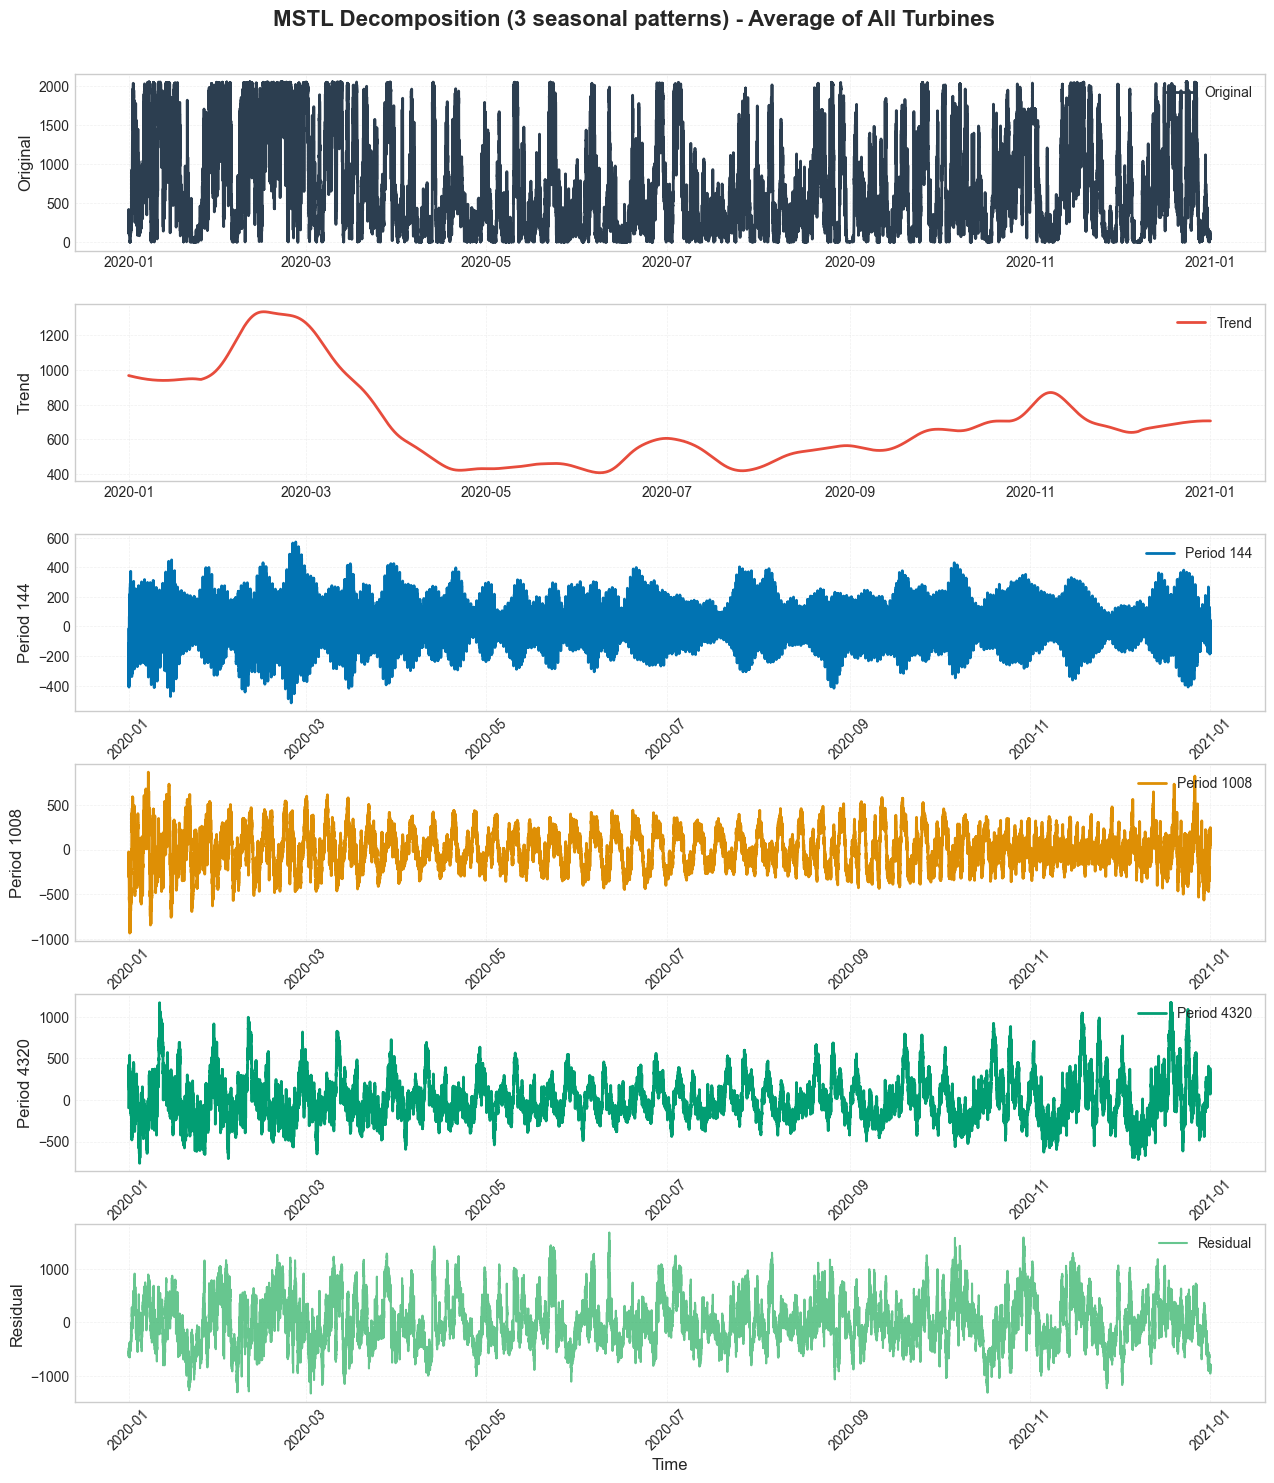

In [50]:
if df_decomposed is not None:
    # Generate file suffix based on what was analyzed
    if turbine_id.lower() == 'all':
        file_suffix = "all_turbines_average"
        sensor_id = "Average of All Turbines"
    else:
        file_suffix = f"turbine_{turbine_id}"
        sensor_id = f"Turbine {turbine_id}"
    
    # Create visualization using SDK component
    plot = MSTLDecompositionPlot(
        decomposition_data=df_decomposed,
        timestamp_column='timestamp',
        value_column='target',
        sensor_id=sensor_id
    )
    
    fig = plot.plot()
    
    # Save using the plot component
    filename = OUTPUT_DIR / f"decomposition_{file_suffix}.png"
    plot.save(filename, dpi=150)
    
    print(f"Saved visualization: {filename}")
else:
    print("Cannot visualize - decomposition failed")

## Step 13: Variance Analysis

In [51]:
if df_decomposed is not None:
    print("Variance Analysis")
    print("="*80)
    
    seasonal_cols = [col for col in df_decomposed.columns if col.startswith('seasonal_')]
    
    total_var = df_decomposed['target'].var()
    trend_var = df_decomposed['trend'].dropna().var()
    residual_var = df_decomposed['residual'].dropna().var()
    
    print(f"\nTotal variance: {total_var:.2f}")
    print()
    print(f"Breakdown:")
    print(f"  Trend:          {trend_var:>12.2f} ({trend_var/total_var*100:>6.2f}%)")
    
    combined_seasonal = 0
    for col, pattern_name in zip(seasonal_cols, pattern_names):
        seasonal_var = df_decomposed[col].dropna().var()
        combined_seasonal += seasonal_var
        print(f"  {pattern_name.capitalize()} Seasonal: {seasonal_var:>12.2f} ({seasonal_var/total_var*100:>6.2f}%)")
    
    print(f"  Residual:       {residual_var:>12.2f} ({residual_var/total_var*100:>6.2f}%)")
    print()
    print(f"  Combined Seasonal: {combined_seasonal:>12.2f} ({combined_seasonal/total_var*100:>6.2f}%)")
else:
    print("Cannot analyze - decomposition failed")

Variance Analysis

Total variance: 417360.75

Breakdown:
  Trend:              61575.36 ( 14.75%)
  Daily Seasonal:     15269.46 (  3.66%)
  Weekly Seasonal:     43585.68 ( 10.44%)
  Monthly Seasonal:     64838.16 ( 15.54%)
  Residual:          199782.16 ( 47.87%)

  Combined Seasonal:    123693.30 ( 29.64%)


## Step 14: Zoom into First 14 Days

Saved: output_images\patterns_14days.png
Saved zoomed visualization: output_images\patterns_14days.png


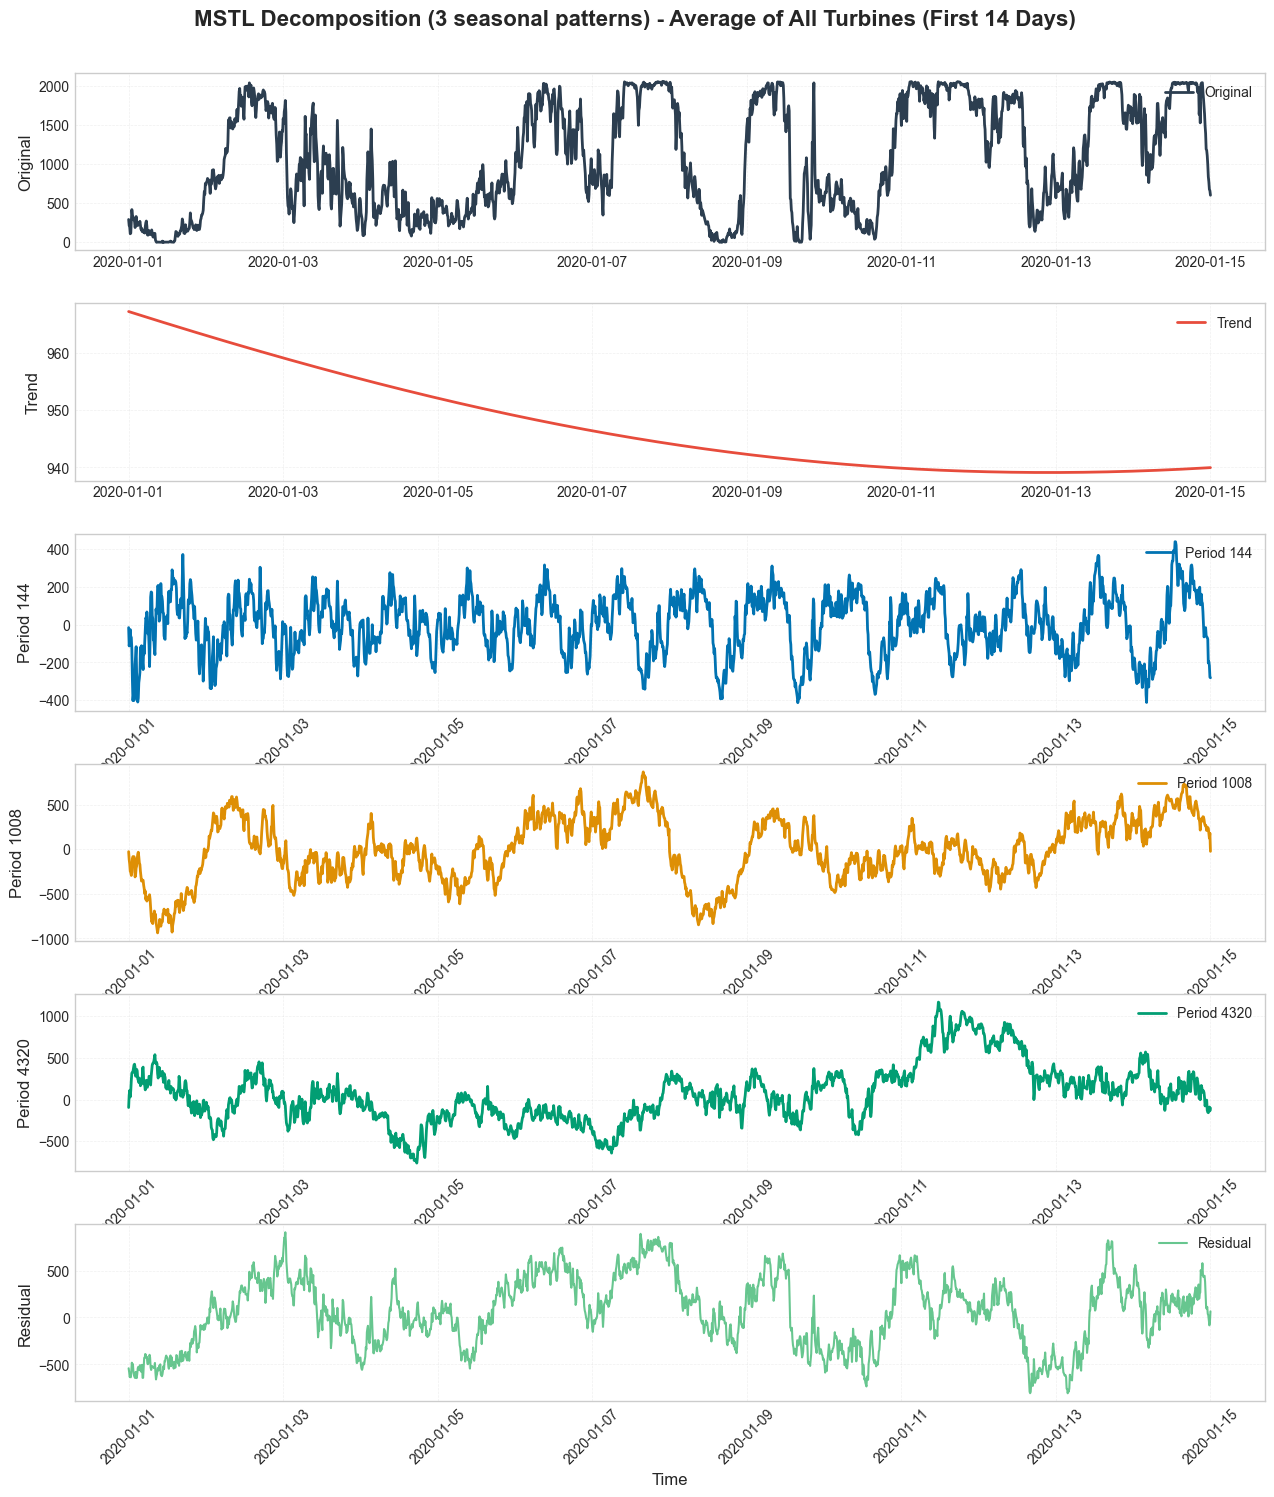

In [52]:
if df_decomposed is not None:
    start = df_decomposed['timestamp'].min()
    end = start + pd.Timedelta(days=14)
    
    df_zoom = df_decomposed[df_decomposed['timestamp'] <= end].copy()
    
    # Generate sensor_id for the zoom plot
    if turbine_id.lower() == 'all':
        sensor_id_zoom = "Average of All Turbines (First 14 Days)"
    else:
        sensor_id_zoom = f"Turbine {turbine_id} (First 14 Days)"
    
    # Create visualization using SDK component for zoomed view
    plot_zoom = MSTLDecompositionPlot(
        decomposition_data=df_zoom,
        timestamp_column='timestamp',
        value_column='target',
        sensor_id=sensor_id_zoom
    )
    
    fig = plot_zoom.plot()
    output_file = OUTPUT_DIR / 'patterns_14days.png'
    plot_zoom.save(output_file, dpi=150)
    
    print(f"Saved zoomed visualization: {output_file}")
else:
    print("Cannot visualize - decomposition failed")

## Step 15: Save Results

In [20]:
if df_decomposed is not None:
    print("Saving results...")
    print("="*80)
    
    # Generate file suffix based on what was analyzed
    if turbine_id.lower() == 'all':
        file_suffix = "all_turbines_average"
    else:
        file_suffix = f"turbine_{turbine_id}"
    
    parquet_file = f"decomposition_{file_suffix}.parquet"
    df_decomposed.to_parquet(parquet_file, index=False)
    print(f"Saved: {parquet_file}")
    
    seasonal_cols = [col for col in df_decomposed.columns if col.startswith('seasonal_')]
    
    total_var = df_decomposed['target'].var()
    trend_var = df_decomposed['trend'].dropna().var()
    residual_var = df_decomposed['residual'].dropna().var()
    
    variance_dict = {
        'trend_pct': float(trend_var / total_var * 100),
        'residual_pct': float(residual_var / total_var * 100)
    }
    
    total_seasonal_var = 0
    for col in seasonal_cols:
        period = int(col.split('_')[1])
        var = df_decomposed[col].dropna().var()
        variance_dict[f'seasonal_{period}_pct'] = float(var / total_var * 100)
        total_seasonal_var += var
    
    variance_dict['combined_seasonal_pct'] = float(total_seasonal_var / total_var * 100)
    
    metadata = {
        'turbine_id': turbine_id,
        'analysis_type': 'averaged' if turbine_id.lower() == 'all' else 'single_turbine',
        'duration_days': float((df_decomposed['timestamp'].max() - df_decomposed['timestamp'].min()).days),
        'data_points': len(df_decomposed),
        'resampling': {
            'frequency': '10 minutes',
            'aggregation': 'mean'
        },
        'interpolation': {
            'method': 'time',
            'limit': interpolation_limit if interpolation_limit else 'none',
            'values_interpolated': int(interpolated_count)
        },
        'outlier_handling': outlier_metadata,
        'patterns': pattern_names,
        'periods': {f'period_{p}': p for p in periods},
        'time_range': {
            'start': str(df_decomposed['timestamp'].min()),
            'end': str(df_decomposed['timestamp'].max())
        },
        'variance_explained': variance_dict
    }
    
    metadata_file = f"decomposition_{file_suffix}.json"
    with open(metadata_file, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"Saved: {metadata_file}")
    
    print("\nSummary:")
    print(f"  Analysis: {turbine_id}")
    print(f"  Duration: {metadata['duration_days']:.1f} days")
    for pattern_name in pattern_names:
        period = pattern_map[pattern_name]
        pct = variance_dict[f'seasonal_{period}_pct']
        print(f"  {pattern_name.capitalize()} seasonality: {pct:.2f}%")
    print(f"  Residual: {variance_dict['residual_pct']:.2f}%")
else:
    print("Cannot save - decomposition failed")

Saving results...
Saved: decomposition_all_turbines_average.parquet
Saved: decomposition_all_turbines_average.json

Summary:
  Analysis: all
  Duration: 365.0 days
  Daily seasonality: 3.66%
  Weekly seasonality: 10.44%
  Monthly seasonality: 15.54%
  Residual: 47.87%
